In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import json
from multiprocessing import cpu_count
from scipy.sparse.linalg import eigs

# プロジェクトルートをパスに追加
current_dir = os.path.dirname(os.path.abspath('.'))
sys.path.append(current_dir)
sys.path.append(os.path.abspath(os.path.join(current_dir, "..")))

from simulation.network import Network, ER

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [13]:
data_dir = os.path.join(current_dir, f"data_ER_N=100_r_high=1.0_q=0_exp")
print(data_dir)

# ディレクトリ内のファイル一覧を取得
files = os.listdir(data_dir)
print("files: ")
for file in files:
    print(f" |__ {file}")

/Users/mikamikojirou/sir-hawkes/data_ER_N=100_r_high=1.0_q=0_exp
files: 
 |__ common_network.npz
 |__ 07_results.npz
 |__ 02_results.npz
 |__ config.json
 |__ 01_results.npz
 |__ 04_results.npz
 |__ 03_results.npz
 |__ 06_results.npz
 |__ 05_results.npz
 |__ r_frac_values.npy
 |__ 00_results.npz


In [16]:
config = json.load(open(os.path.join(data_dir, "config.json"), "r"))
print(config)

N = config["nodes"]
r_high = config["r_high"]
q = config["q"]
repeats = config["repeats"]
t_max = config["t_max"]
workers = config["workers"]

is_network_common = config["is_network_common"]

if is_network_common:
    network_data = np.load(os.path.join(data_dir, "common_network.npz"))
    N = network_data["N"]
    k_ave = network_data["k_ave"]
    edge_list = network_data["edge_list"]
    address_list = network_data["address_list"] 
    cursor_list = network_data["cursor_list"]
    network = Network(N, k_ave, edge_list, address_list, cursor_list)
    print(f"network is common: N={N}, k_ave={k_ave}")

    A = np.zeros((N, N), dtype=float)
    for i in range(N):
        for jidx in range(address_list[i], cursor_list[i]):
            j = edge_list[jidx]
            A[i, j] = 1
            A[j, i] = 1

    # 最大の固有値（絶対値が最大のものを1つ取得）
    eigvals, eigvecs = eigs(A, k=1, which='LM')

    print("最大固有値:", eigvals[0].real)
    

r_frac_values = np.load(os.path.join(data_dir, "r_frac_values.npy"))
print(f"r_frac min: {r_frac_values.min()}")
print(f"r_frac max: {r_frac_values.max()}")
print(f"r_frac length: {len(r_frac_values)}")

{'nodes': 100, 'avg_degree': 10.0, 'initial_infected': 1, 't_max': 100, 'repeats': 40, 'q': 0, 'r_high': 1.0, 'output_dir': 'data_ER_N=100_r_high=1.0_q=0_exp', 'workers': 8, 'is_network_common': True}
network is common: N=100, k_ave=9.6
最大固有値: 10.485888488878562
r_frac min: 0.08
r_frac max: 0.12
r_frac length: 100


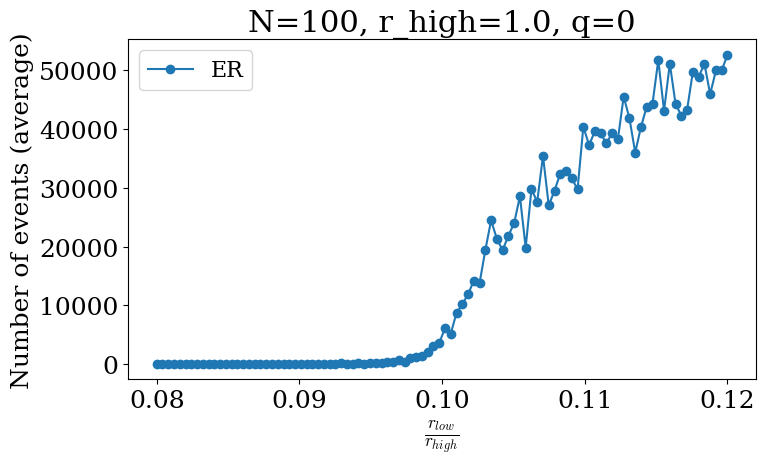

In [17]:
event_num_dict = {}

#---- 設定 ----
n_workers = cpu_count()
R = len(r_frac_values)

#---- 1) 各 worker の event_times をキャッシュ ----
worker_data = []
for wid in range(n_workers):
    path = os.path.join(data_dir, f"{wid:02d}_results.npz")
    with np.load(path, allow_pickle=True) as d:
        # d["event_times"] は shape=(R, repeats) の object 配列
        worker_data.append(d["event_times"])

#---- 2) 合計長さ＆有効サンプル数を r_frac_idx ごとに初期化 ----
total_lengths = np.zeros(R, dtype=float)
valid_counts  = np.zeros(R, dtype=int)

#---- 3) 各 worker のデータから集計 ----
for ev_times in worker_data:
    # 各要素の長さを一括取得 (shape=(A, R))
    lengths = np.vectorize(lambda arr: arr.shape[0])(ev_times)
    # 長さが 20 以上のものだけをカウント対象に
    mask = (lengths > 1)

    # r_frac_idx ごとに合計長さを足し込み
    total_lengths += (lengths * mask).sum(axis=1)
    # r_frac_idx ごとに有効サンプル数を足し込み
    valid_counts  += mask.sum(axis=1)

#---- 4) 平均を計算 ----
event_num_ave = total_lengths / valid_counts

event_num_dict["ER"] = event_num_ave


#---- 5) 描画 ----
fig, ax = plt.subplots(figsize=(8, 5))
for key, value in event_num_dict.items():
    ax.plot(r_frac_values, value, marker="o", label=key)
ax.set_title(f"N={N}, r_high={r_high}, q={q}")
ax.set_xlabel(r"$\frac{r_{low}}{r_{high}}$")
ax.set_ylabel("Number of events (average)")
ax.legend()
plt.tight_layout()
plt.show()


In [58]:
data_dir = os.path.join(current_dir, f"data_ER_N=100_r_high=0.5_q=0.02_exp")
print(data_dir)

# ディレクトリ内のファイル一覧を取得
files = os.listdir(data_dir)
print("files: ")
for file in files:
    print(f" |__ {file}")

/Users/mikamikojirou/sir-hawkes/data_ER_N=100_r_high=0.5_q=0.02_exp
files: 
 |__ common_network.npz
 |__ 07_results.npz
 |__ 02_results.npz
 |__ config.json
 |__ 01_results.npz
 |__ 04_results.npz
 |__ 03_results.npz
 |__ 06_results.npz
 |__ 05_results.npz
 |__ r_frac_values.npy
 |__ 00_results.npz


In [64]:
config = json.load(open(os.path.join(data_dir, "config.json"), "r"))
print(config)

N = config["nodes"]
r_high = config["r_high"]
q = config["q"]
repeats = config["repeats"]
t_max = config["t_max"]
workers = config["workers"]

is_network_common = config["is_network_common"]

if is_network_common:
    network_data = np.load(os.path.join(data_dir, "common_network.npz"))
    N = network_data["N"]
    k_ave = network_data["k_ave"]
    edge_list = network_data["edge_list"]
    address_list = network_data["address_list"] 
    cursor_list = network_data["cursor_list"]
    network = Network(N, k_ave, edge_list, address_list, cursor_list)
    print(f"network is common: N={N}, k_ave={k_ave}")

    A = np.zeros((N, N), dtype=float)
    for i in range(N):
        for jidx in range(address_list[i], cursor_list[i]):
            j = edge_list[jidx]
            A[i, j] = 1
            A[j, i] = 1

    # 最大の固有値（絶対値が最大のものを1つ取得）
    eigvals, eigvecs = eigs(A, k=1, which='LM')

    print("最大固有値:", eigvals[0].real)
    

r_frac_values = np.load(os.path.join(data_dir, "r_frac_values.npy"))
print(f"r_frac min: {r_frac_values.min()}")
print(f"r_frac max: {r_frac_values.max()}")
print(f"r_frac length: {len(r_frac_values)}")

{'nodes': 100, 'avg_degree': 10.0, 'initial_infected': 1, 't_max': 100, 'repeats': 80, 'q': 0.02, 'r_high': 0.5, 'output_dir': 'data_ER_N=100_r_high=0.5_q=0.02_exp', 'workers': 8, 'environment_info': {'platform': 'Darwin', 'platform_release': '24.4.0', 'machine': 'arm64', 'processor': 'arm', 'hostname': 'mikamitorajirounoMacBook-Air.local', 'cpu_count': 8, 'memory_total': 8589934592, 'is_ec2': False, 'ec2_instance_type': None, 'environment_type': 'Local-Darwin'}, 'is_network_common': True}
network is common: N=100, k_ave=10.22
最大固有値: 11.121570567922921
r_frac min: 0.1
r_frac max: 0.2
r_frac length: 100


In [71]:
import numpy as np
from scipy.sparse.linalg import eigs

A = np.zeros((N, N), dtype=float)
iterations = 10
eigvals = np.zeros(iterations)
eigvecs = np.zeros((iterations, N))

for i in range(N):
    for jidx in range(address_list[i], cursor_list[i]):
        j = edge_list[jidx]
        A[i, j] = 1
        A[j, i] = 1

early_num = int(N * q)

# 実数スペクトル半径を扱う例
eigvals = np.zeros(iterations, dtype=float)
eigvecs = np.zeros((iterations, N), dtype=float)

for itr in range(iterations):
    # B の構築までは同じ
    weights = np.ones(N) * r_high
    nodes = np.arange(N)
    np.random.shuffle(nodes)
    late = nodes[int(N*q):]
    weights[late] = r_high * 0.20
    B = np.diag(weights)

    # 1 個の固有値・固有ベクトルを求める
    w, v = eigs(A @ B, k=1, which='LM')

    # 絶対値を取って実数配列に格納
    eigvals[itr]  = abs(w[0])
    print(f"eigvals[{itr}]: {eigvals[itr]}")
    eigvecs[itr] = abs(v[:, 0])

print("平均スペクトル半径:", eigvals.mean())


eigvals[0]: 1.2064791639927805
eigvals[1]: 1.220247155938958
eigvals[2]: 1.2736267652071132
eigvals[3]: 1.1968126170946594
eigvals[4]: 1.2106035863591806
eigvals[5]: 1.1887115942872062
eigvals[6]: 1.2007523378566471
eigvals[7]: 1.2329813235358908
eigvals[8]: 1.1881876756509318
eigvals[9]: 1.1696088991073488
平均スペクトル半径: 1.2088011119030715


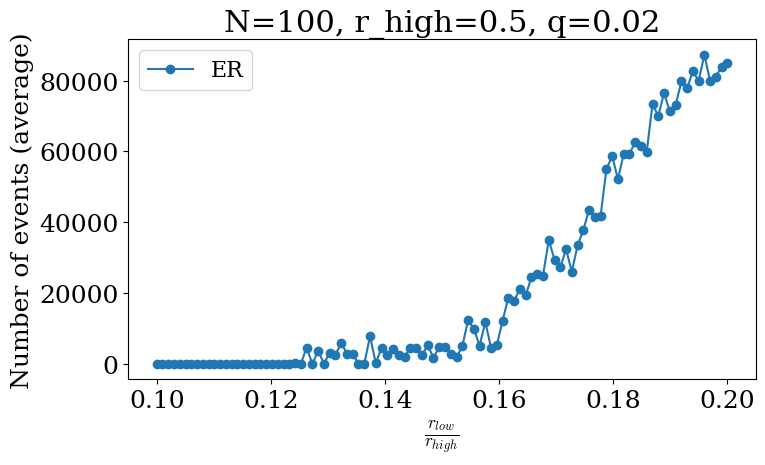

In [75]:
event_num_dict = {}

#---- 設定 ----
n_workers = cpu_count()
R = len(r_frac_values)

#---- 1) 各 worker の event_times をキャッシュ ----
worker_data = []
for wid in range(n_workers):
    path = os.path.join(data_dir, f"{wid:02d}_results.npz")
    with np.load(path, allow_pickle=True) as d:
        # d["event_times"] は shape=(R, repeats) の object 配列
        worker_data.append(d["event_times"])

#---- 2) 合計長さ＆有効サンプル数を r_frac_idx ごとに初期化 ----
total_lengths = np.zeros(R, dtype=float)
valid_counts  = np.zeros(R, dtype=int)

#---- 3) 各 worker のデータから集計 ----
for ev_times in worker_data:
    # 各要素の長さを一括取得 (shape=(A, R))
    lengths = np.vectorize(lambda arr: arr.shape[0])(ev_times)
    # 長さが 20 以上のものだけをカウント対象に
    mask = (lengths > 20)

    # r_frac_idx ごとに合計長さを足し込み
    total_lengths += (lengths * mask).sum(axis=1)
    # r_frac_idx ごとに有効サンプル数を足し込み
    valid_counts  += mask.sum(axis=1)

#---- 4) 平均を計算 ----
event_num_ave = total_lengths / valid_counts

event_num_dict["ER"] = event_num_ave


#---- 5) 描画 ----
fig, ax = plt.subplots(figsize=(8, 5))
for key, value in event_num_dict.items():
    ax.plot(r_frac_values, value, marker="o", label=key)
ax.set_title(f"N={N}, r_high={r_high}, q={q}")
ax.set_xlabel(r"$\frac{r_{low}}{r_{high}}$")
ax.set_ylabel("Number of events (average)")
ax.legend()
plt.tight_layout()
plt.show()


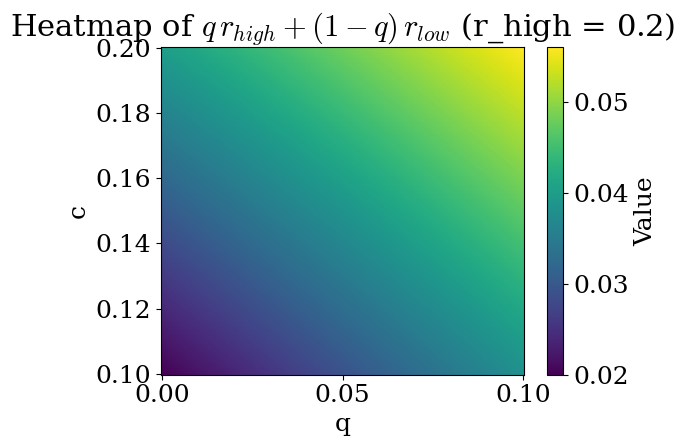

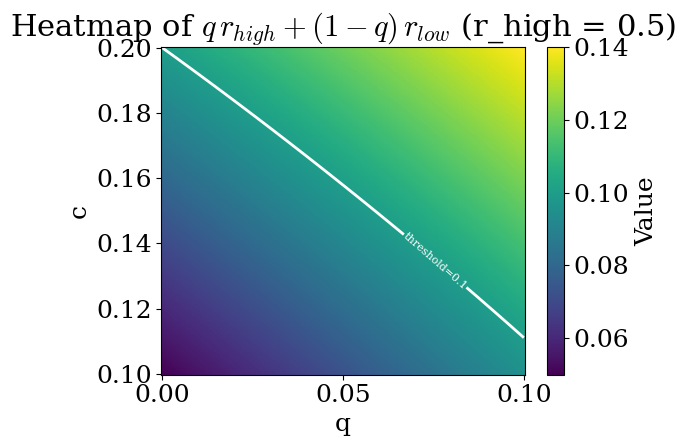

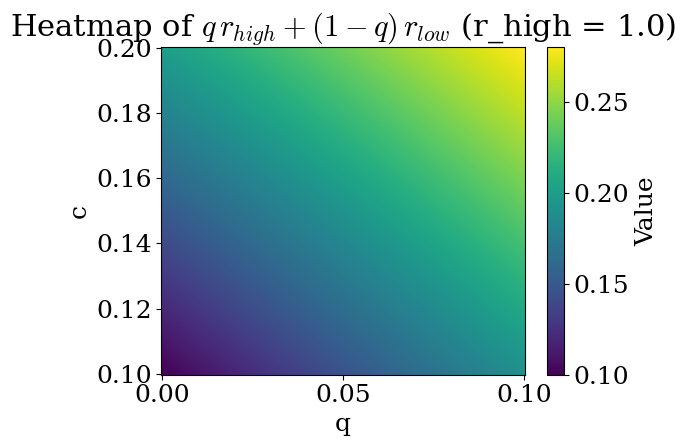

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r_high_list = [0.2, 0.5, 1.0]
q = np.linspace(0, 0.1, 200)
c = np.linspace(0.1, 0.2, 200)
Q, C = np.meshgrid(q, c)

# Threshold
value_c = 0.1

# Generate a separate heatmap for each r_high value
for r_high in r_high_list:
    Z = r_high * (Q + (1 - Q) * C)
    
    plt.figure()
    # Plot the continuous heatmap
    pcm = plt.pcolormesh(Q, C, Z, shading='auto')
    plt.colorbar(pcm, label='Value')
    
    # Overlay contour at the threshold
    CS = plt.contour(Q, C, Z, levels=[value_c], colors='white', linewidths=2)
    plt.clabel(CS, fmt={value_c: f'threshold={value_c}'}, inline=True, fontsize=8, colors='white')
    
    plt.xlabel('q')
    plt.ylabel('c')
    plt.title(rf'Heatmap of $q\,r_{{high}} + (1-q)\,r_{{low}}$ (r_high = {r_high})')
    plt.tight_layout()
    plt.show()
